# Atividade 3 - Diagnóstico de falhas baseado em dados

Métodos usados:

- PCA: conforme a formulação usada por Yin et al
- Autoencoder undercomplete: baseado no artigo de Spina et al

Falhas analisadas: IDV(1), IDV(3) e IDV(5)

In [4]:
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from zipfile import ZipFile
from scipy.stats import f, norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, roc_auc_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

FAULTS = {
    1: "IDV(1)",
    3: "IDV(3)",
    5: "IDV(5)",
}

SAMPLE_TIME_MIN = 3
FAULT_START_HOUR = 8
FAULT_START_SAMPLE = int((FAULT_START_HOUR * 60) / SAMPLE_TIME_MIN)
PCA_COMPONENTS = 9
CONFIDENCE_LEVEL = 0.99
AE_THRESHOLD_PERCENTILE = 99

print("Amostra de início da falha:", FAULT_START_SAMPLE)

ZIP_PATH = Path("TE_process.zip")
ZIP_FILES = {
    "train_normal": "TE_process/d00.dat",
    "test_normal": "TE_process/d00_te.dat",
    1: "TE_process/d01_te.dat",
    3: "TE_process/d03_te.dat",
    5: "TE_process/d05_te.dat",
}

Amostra de início da falha: 160



## Carregamento dos dados

In [13]:
def read_dat_from_zip(internal_path):
    with ZipFile(ZIP_PATH, "r") as zf:
        with zf.open(internal_path) as file:
            df = pd.read_csv(file, sep=r"\s+", header=None, engine="python")

    return df.apply(pd.to_numeric, errors="raise")

X_train_raw = read_dat_from_zip(ZIP_FILES["train_normal"]).T.reset_index(drop=True)
X_normal_test_raw = read_dat_from_zip(ZIP_FILES["test_normal"])

fault_data_raw = {
    fault_id: read_dat_from_zip(ZIP_FILES[fault_id])
    for fault_id in FAULTS
}

for fault_id, df in fault_data_raw.items():
    if df.shape != (960, 52):
        raise ValueError(
            f"d{fault_id:02d}_te.dat deveria ter shape (960, 52), "
            f"mas ficou {df.shape}"
        )

print("Treino normal:", X_train_raw.shape)
print("Teste normal:", X_normal_test_raw.shape)
for fault_id, df in fault_data_raw.items():
    print(f"Falha {fault_id}:", df.shape)

Treino normal: (500, 52)
Teste normal: (960, 52)
Falha 1: (960, 52)
Falha 3: (960, 52)
Falha 5: (960, 52)


## 3. 33 variáveis

In [14]:
def selecionar_yin33(df):
    xmeas_1_22 = list(range(0, 22))
    xmv_1_11 = list(range(41, 52))
    cols = xmeas_1_22 + xmv_1_11
    return df.iloc[:, cols].copy()

X_train_raw = selecionar_yin33(X_train_raw)
X_normal_test_raw = selecionar_yin33(X_normal_test_raw)

fault_data_raw = {
    fault_id: selecionar_yin33(df)
    for fault_id, df in fault_data_raw.items()
}

print("Após seleção:")
print("Treino normal:", X_train_raw.shape)
print("Teste normal:", X_normal_test_raw.shape)
for fault_id, df in fault_data_raw.items():
    print(f"Falha {fault_id}:", df.shape)

Após seleção:
Treino normal: (500, 33)
Teste normal: (960, 33)
Falha 1: (960, 33)
Falha 3: (960, 33)
Falha 5: (960, 33)


## 4. Normalização

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_normal_test = scaler.transform(X_normal_test_raw)

fault_data = {
    fault_id: scaler.transform(df)
    for fault_id, df in fault_data_raw.items()
}

## 5. PCA

In [ ]:
pca = PCA(n_components=None, random_state=RANDOM_STATE)
pca.fit(X_train)

n_samples, n_features = X_train.shape
l = PCA_COMPONENTS
components_l = pca.components_[:l]
variancias_l = pca.explained_variance_[:l]
variancias_residuais = pca.explained_variance_[l:]

def pca_indices(X):
    X_centered = X - pca.mean_
    scores = X_centered @ components_l.T
    X_hat = scores @ components_l + pca.mean_

    residual = X - X_hat
    spe = np.sum(residual**2, axis=1)
    t2 = np.sum((scores**2) / variancias_l, axis=1)

    return spe, t2


def pca_thresholds(confidence=0.99):
    t2_limit = (
        l * (n_samples**2 - 1)
        / (n_samples * (n_samples - l))
        * f.ppf(confidence, l, n_samples-l)
    )

    theta1 = np.sum(variancias_residuais)
    theta2 = np.sum(variancias_residuais ** 2)
    theta3 = np.sum(variancias_residuais** 3)

    if theta1 <= 0 or theta2 <= 0:
        spe_limit = 0.0
    else:
        h0 = 1 - (2 * theta1 * theta3)/ (3 * theta2**2)
        ca = norm.ppf(confidence)
        spe_limit = theta1 * (
            (ca * np.sqrt(2 * theta2 * h0**2) / theta1)
            + 1
            + (theta2 * h0 * (h0 - 1) / theta1**2)
        ) ** (1 / h0)

    return spe_limit, t2_limit

pca_spe_threshold, pca_t2_threshold = pca_thresholds(CONFIDENCE_LEVEL)

pca_normal_spe, pca_normal_t2 = pca_indices(X_normal_test)

pca_normal_score = np.maximum(
    pca_normal_spe / pca_spe_threshold,
    pca_normal_t2 / pca_t2_threshold,
)

print("Componentes PCA usados:", PCA_COMPONENTS)
print("Variância explicada acumulada:", round(pca.explained_variance_ratio_[:l].sum(), 4))
print("Limiar SPE:", pca_spe_threshold)
print("Limiar T²:", pca_t2_threshold)

Componentes PCA usados: 9
Variância explicada acumulada: 0.6767
Limiar SPE: 23.453219480633894
Limiar T²: 22.39477509405858


## 6. Autoencoder

In [9]:
import sys
import subprocess

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tensorflow"])
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)

input_dim = X_train.shape[1]

# Undercomplete -> o código eh menor que a entrada
code_size = 16

autoencoder = keras.Sequential([
    keras.Input(shape=(input_dim,)),
    layers.Dense(code_size, activation="tanh", name="bottleneck"),
    layers.Dense(input_dim, activation="linear", name="reconstruction"),
])

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

history = autoencoder.fit(
    X_train,
    X_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

def ae_reconstruction_error(X):
    X_hat = autoencoder.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

ae_normal_error = ae_reconstruction_error(X_normal_test)
ae_threshold = np.percentile(ae_normal_error, AE_THRESHOLD_PERCENTILE)

print("Dimensão de entrada:", input_dim)
print("Dimensão do code:", code_size)
print("Épocas treinadas:", len(history.history["loss"]))
print("Limiar Autoencoder:", ae_threshold)

Dimensão de entrada: 33
Dimensão do code: 16
Épocas treinadas: 80
Limiar Autoencoder: 0.856793986393229


## 7. FAR, FDR e AUC

In [10]:
def evaluate_fault(score_normal, score_fault, threshold):
    normal_region = np.r_[score_normal, score_fault[:FAULT_START_SAMPLE]]
    faulty_region = score_fault[FAULT_START_SAMPLE:]

    far = np.mean(normal_region > threshold) * 100
    fdr = np.mean(faulty_region > threshold) * 100

    y_true = np.r_[np.zeros(len(normal_region)), np.ones(len(faulty_region))]
    scores = np.r_[normal_region, faulty_region]

    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)

    return {
        "FAR (%)": far,
        "FDR (%)": fdr,
        "AUC": auc,
        "fpr": fpr,
        "tpr": tpr,
    }

results = []
curves = {}

for fault_id, X_fault in fault_data.items():
    fault_spe, fault_t2 = pca_indices(X_fault)
    fault_pca_score = np.maximum(
        fault_spe / pca_spe_threshold,
        fault_t2 / pca_t2_threshold,
    )

    eval_pca = evaluate_fault(pca_normal_score, fault_pca_score, threshold=1.0)

    results.append({
        "Método": "PCA",
        "Falha": f"IDV({fault_id})",
        "FAR (%)": eval_pca["FAR (%)"],
        "FDR (%)": eval_pca["FDR (%)"],
        "AUC": eval_pca["AUC"],
    })

    curves[("PCA", fault_id)] = {
        "score": fault_pca_score,
        "threshold": 1.0,
        "fpr": eval_pca["fpr"],
        "tpr": eval_pca["tpr"],
        "spe": fault_spe,
        "t2": fault_t2,
    }

    error_fault_ae = ae_reconstruction_error(X_fault)
    eval_ae = evaluate_fault(ae_normal_error, error_fault_ae, threshold=ae_threshold)

    results.append({
        "Método": "Autoencoder",
        "Falha": f"IDV({fault_id})",
        "FAR (%)": eval_ae["FAR (%)"],
        "FDR (%)": eval_ae["FDR (%)"],
        "AUC": eval_ae["AUC"],
    })

    curves[("Autoencoder", fault_id)] = {
        "score": error_fault_ae,
        "threshold": ae_threshold,
        "fpr": eval_ae["fpr"],
        "tpr": eval_ae["tpr"],
    }

results_df = pd.DataFrame(results)
results_df[["FAR (%)", "FDR (%)", "AUC"]] = results_df[["FAR (%)", "FDR (%)", "AUC"]].round(4)

results_df

,Método,Falha,FAR (%),FDR (%),AUC
0,PCA,IDV(1),5.3571,99.875,0.9998
1,Autoencoder,IDV(1),0.8929,99.750,0.9999
2,PCA,IDV(3),5.2679,12.875,0.5848
3,Autoencoder,IDV(3),1.0714,4.500,0.5830
4,PCA,IDV(5),5.4464,33.625,0.7038
5,Autoencoder,IDV(5),0.8929,27.750,0.7642


## 8. Gráficos

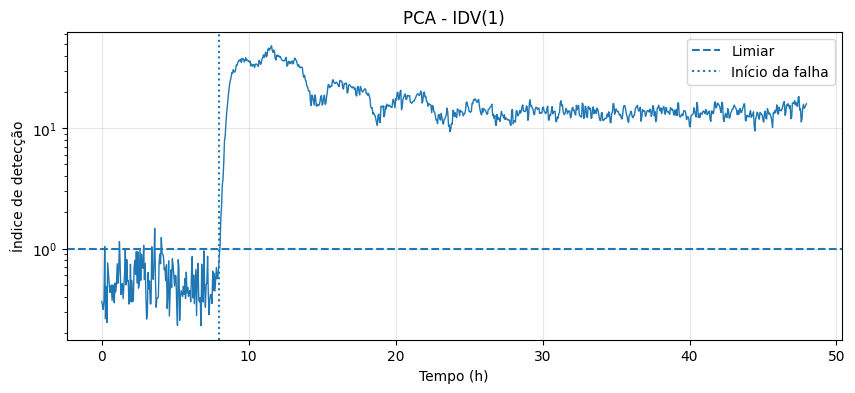

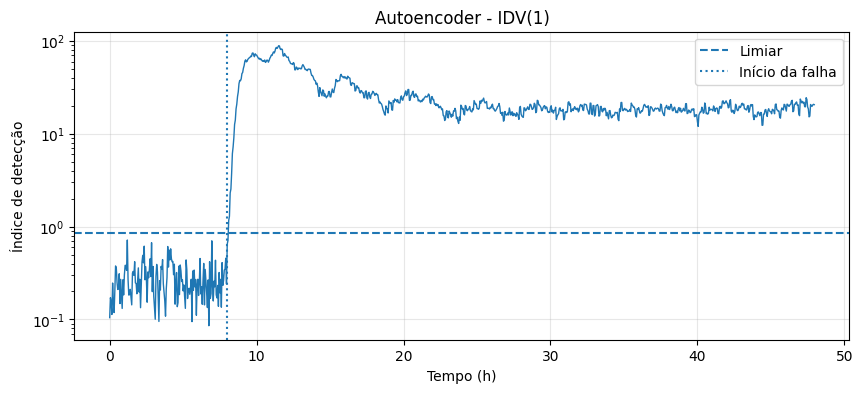

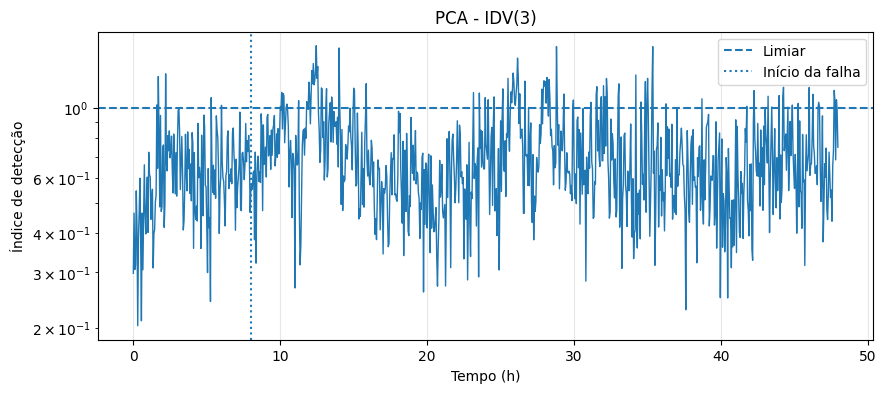

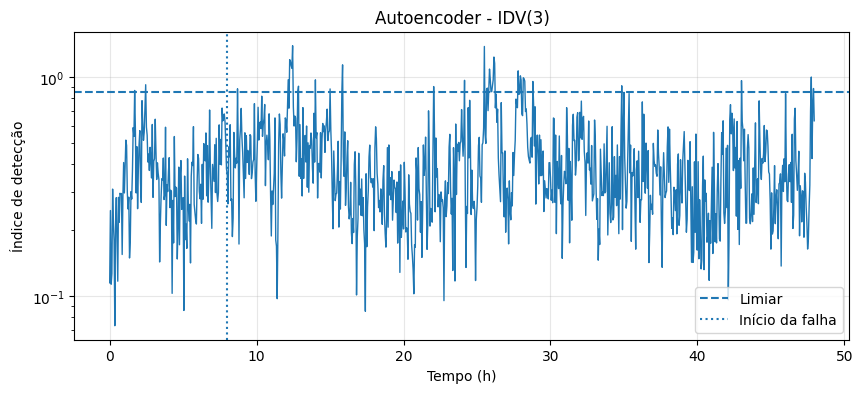

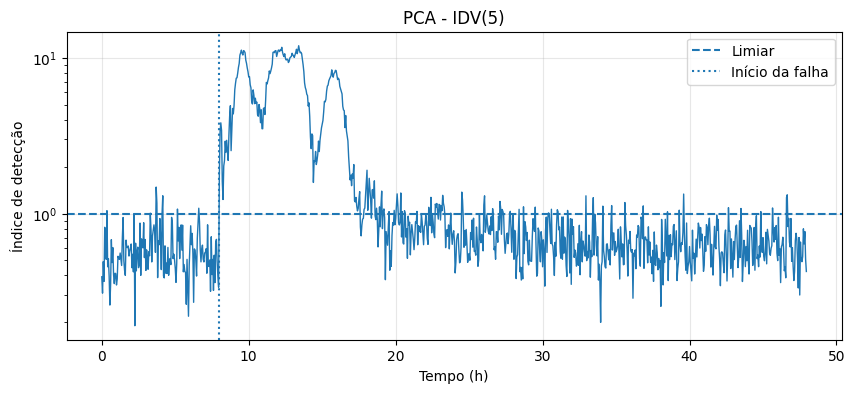

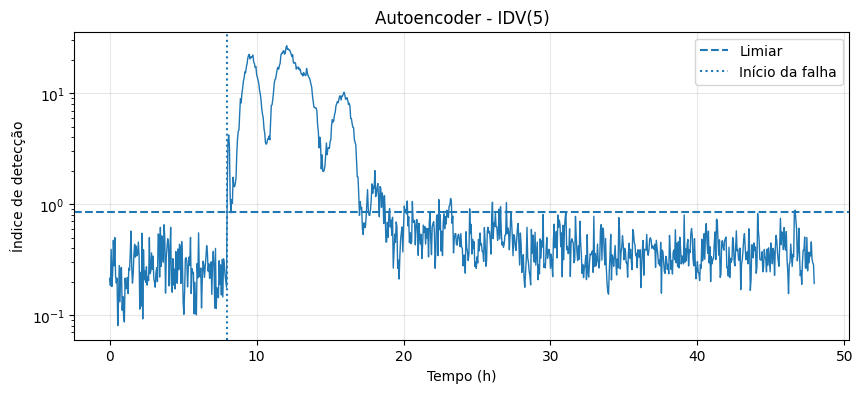

In [11]:
def plot_detection_timeline(method, fault_id):
    data = curves[(method, fault_id)]
    score = data["score"]
    threshold = data["threshold"]

    time_h = np.arange(len(score)) * SAMPLE_TIME_MIN / 60

    plt.figure(figsize=(10, 4))
    plt.plot(time_h, score, linewidth=1)
    plt.axhline(threshold, linestyle="--", label="Limiar")
    plt.axvline(FAULT_START_HOUR, linestyle=":", label="Início da falha")
    plt.yscale("log")
    plt.xlabel("Tempo (h)")
    plt.ylabel("Índice de detecção")
    plt.title(f"{method} - IDV({fault_id})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


for fault_id in FAULTS:
    plot_detection_timeline("PCA", fault_id)
    plot_detection_timeline("Autoencoder", fault_id)

## 9. Curvas ROC

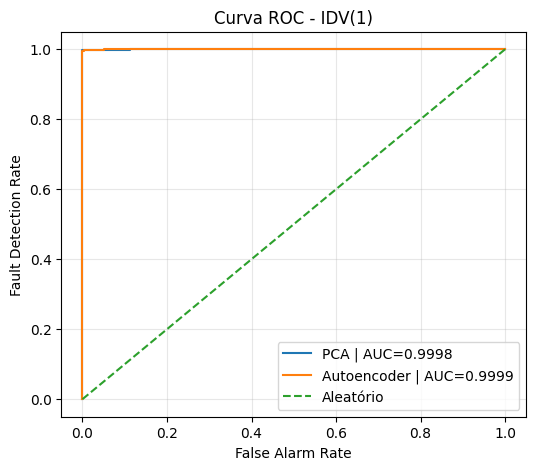

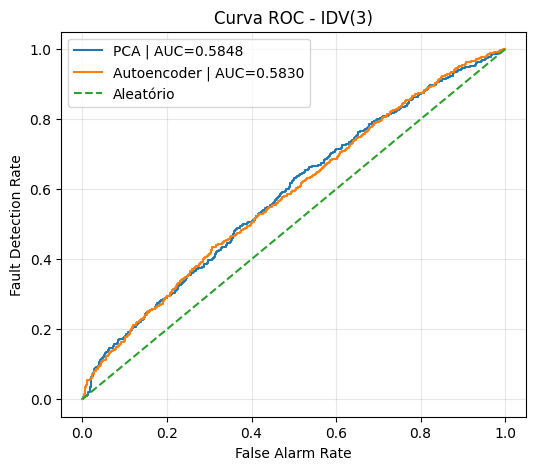

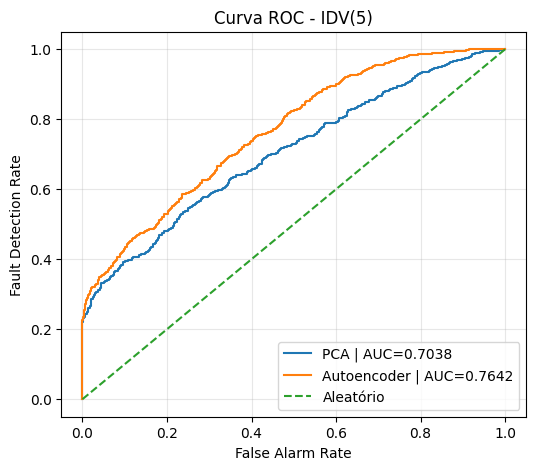

In [12]:
def plot_roc_for_fault(fault_id):
    plt.figure(figsize=(6, 5))

    for method in ["PCA", "Autoencoder"]:
        data = curves[(method, fault_id)]
        auc_value = results_df[
            (results_df["Método"] == method) &
            (results_df["Falha"] == f"IDV({fault_id})")
        ]["AUC"].iloc[0]

        plt.plot(data["fpr"], data["tpr"], label=f"{method} | AUC={auc_value:.4f}")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Aleatório")
    plt.xlabel("False Alarm Rate")
    plt.ylabel("Fault Detection Rate")
    plt.title(f"Curva ROC - IDV({fault_id})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

for fault_id in FAULTS:
    plot_roc_for_fault(fault_id)